In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load the scrimmage plays we saved at the end of Phase 1.
# This is the 106,386-row dataset with next_score already assigned.
plays = pd.read_csv("data/scrimmage_2021_2023.csv", low_memory=False)

print(f"Loaded {len(plays):,} scrimmage plays")
print(f"Columns available: {plays.shape[1]}")
print(f"\nnext_score distribution:\n{plays['next_score'].value_counts()}")

Loaded 106,386 scrimmage plays
Columns available: 398

next_score distribution:
next_score
off_td        53418
off_fg        41023
no_score       9057
def_td         2173
def_safety      497
off_safety      218
Name: count, dtype: int64


In [31]:
# We need exactly these columns plus next_score.
# Everything else is either a target leak, a post-hoc stat, or not useful
# for predicting scoring outcome before the play happens.
FEATURE_COLS = [
    "season",                # needed for temporal train/val split in Phase 3
    "game_id",               # useful for game-level grouping in Phase 4 validation
    "down",                  # which down it is; treated as categorical, not 1-2-3-4 ordinal
    "ydstogo",               # yards needed for a first down; directly constrains play-calling
    "yardline_100",          # distance from the opponent's end zone; drives FG probability
    "score_differential",    # score context changes risk tolerance and play-calling dramatically
    "half_seconds_remaining",# time left in the half; affects whether a team can realistically score
]
TARGET = "next_score"

# qtr is intentionally excluded. half_seconds_remaining already captures time
# context, and qtr on top of it acts as a proxy for game script rather than
# adding clean signal. In Phase 3 testing, qtr dominated feature importance
# at 44x the gain of yardline_100, which suppressed field position signal
# entirely. Removing it lets the model weight field position and down properly.

df = plays[FEATURE_COLS + [TARGET]].copy()
before = len(df)
df = df.dropna(subset=FEATURE_COLS + [TARGET])
after = len(df)

print(f"Dropped {before - after:,} rows with null values in core features")
print(f"Working dataset: {after:,} rows")
print(f"\nFeature dtypes:\n{df[FEATURE_COLS].dtypes}")

Dropped 0 rows with null values in core features
Working dataset: 106,386 rows

Feature dtypes:
season                      int64
game_id                       str
down                      float64
ydstogo                   float64
yardline_100              float64
score_differential        float64
half_seconds_remaining    float64
dtype: object


In [32]:
# Before touching anything, verify the data looks like real football.
print("down:               ", sorted(df["down"].unique()))
print("ydstogo range:      ", df["ydstogo"].min(), "--", df["ydstogo"].max())
print("yardline_100 range: ", df["yardline_100"].min(), "--", df["yardline_100"].max())
print("score_diff range:   ", df["score_differential"].min(), "--", df["score_differential"].max())
print("half_sec range:     ", df["half_seconds_remaining"].min(), "--", df["half_seconds_remaining"].max())

# Flag anything suspicious: ydstogo > 99, yardline_100 outside 1-99, down not in 1-4.
bad_ydstogo   = df["ydstogo"] > 50
bad_yardline  = (df["yardline_100"] < 1) | (df["yardline_100"] > 99)
bad_down      = ~df["down"].isin([1, 2, 3, 4])

print(f"\nSuspect ydstogo (>50): {bad_ydstogo.sum()}")
print(f"Suspect yardline_100 (outside 1-99): {bad_yardline.sum()}")
print(f"Suspect down (not 1-4): {bad_down.sum()}")

down:                [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
ydstogo range:       1.0 -- 43.0
yardline_100 range:  1.0 -- 99.0
score_diff range:    -56.0 -- 50.0
half_sec range:      0.0 -- 1800.0

Suspect ydstogo (>50): 0
Suspect yardline_100 (outside 1-99): 0
Suspect down (not 1-4): 0


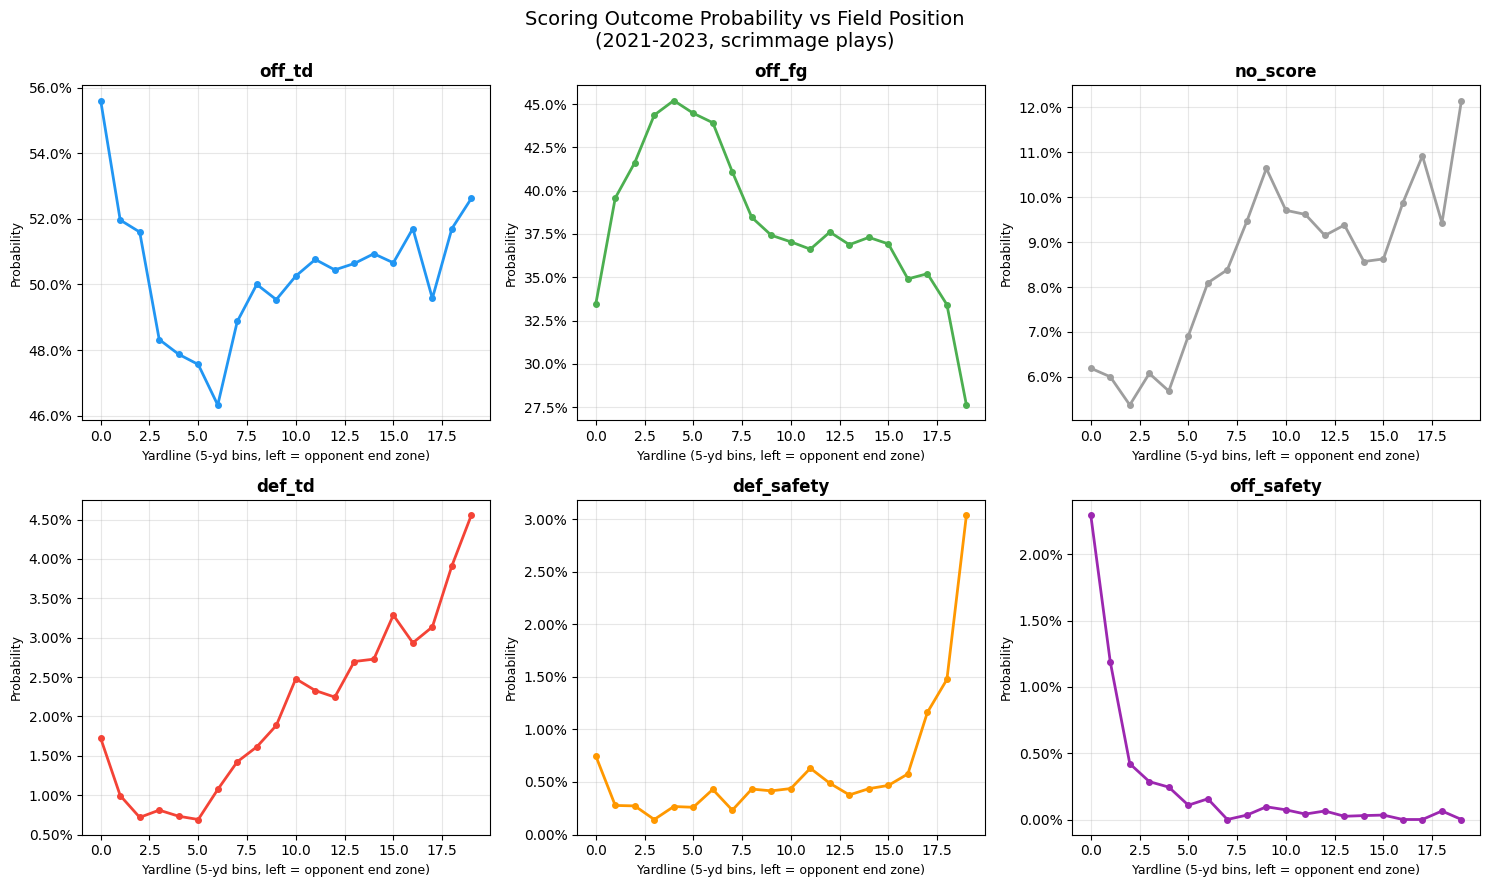

In [33]:
# Bin yardline into 5-yard buckets for a smooth enough picture without
# over-smoothing. 20 bins across 1-99 yards gives ~5 yards each.
df["yardline_bin"] = pd.cut(df["yardline_100"], bins=range(0, 105, 5))

# Compute fraction of each outcome by field position bin.
scoring_probs = (
    df.groupby("yardline_bin")[TARGET]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
outcomes = ["off_td", "off_fg", "no_score", "def_td", "def_safety", "off_safety"]
colors   = ["#2196F3", "#4CAF50", "#9E9E9E", "#F44336", "#FF9800", "#9C27B0"]

for ax, outcome, color in zip(axes.flatten(), outcomes, colors):
    if outcome in scoring_probs.columns:
        ax.plot(
            range(len(scoring_probs)),
            scoring_probs[outcome],
            color=color, linewidth=2, marker="o", markersize=4
        )
    ax.set_title(outcome, fontsize=12, fontweight="bold")
    ax.set_xlabel("Yardline (5-yd bins, left = opponent end zone)", fontsize=9)
    ax.set_ylabel("Probability", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    ax.grid(True, alpha=0.3)

plt.suptitle("Scoring Outcome Probability vs Field Position\n(2021-2023, scrimmage plays)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/yardline_vs_scoring_prob.png", dpi=150, bbox_inches="tight")
plt.show()

# Drop the temp bin column before moving forward.
df = df.drop(columns=["yardline_bin"])

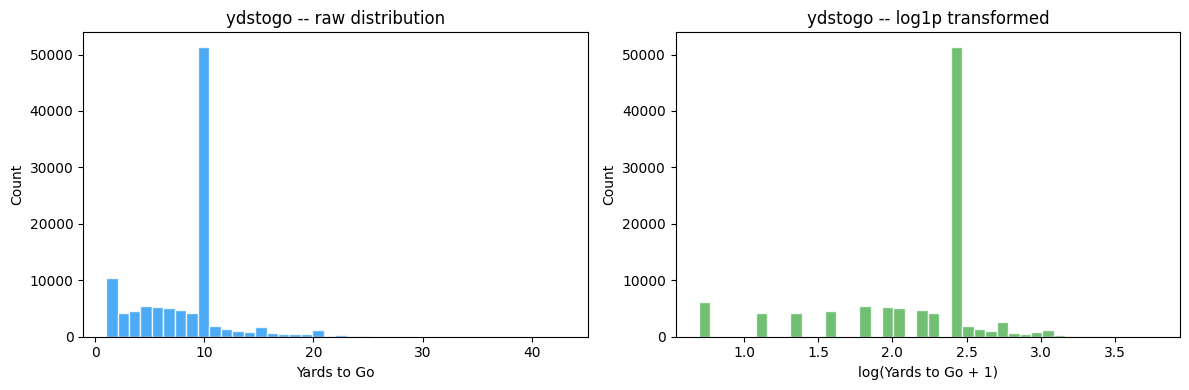

ydstogo skewness (raw):      0.466
ydstogo skewness (log1p):    -1.261


In [34]:
# ydstogo is heavily right-skewed (most plays are 1st-and-10, so mode is 10).
# Worth checking if a log transform makes the distribution more useful to the model.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["ydstogo"], bins=40, color="#2196F3", edgecolor="white", alpha=0.8)
axes[0].set_title("ydstogo -- raw distribution")
axes[0].set_xlabel("Yards to Go")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(df["ydstogo"]), bins=40, color="#4CAF50", edgecolor="white", alpha=0.8)
axes[1].set_title("ydstogo -- log1p transformed")
axes[1].set_xlabel("log(Yards to Go + 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("figures/ydstogo_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ydstogo skewness (raw):      {df['ydstogo'].skew():.3f}")
print(f"ydstogo skewness (log1p):    {np.log1p(df['ydstogo']).skew():.3f}")

In [35]:
# DECISION: Apply log1p to ydstogo.
# The difference between 1 yard to go and 5 yards to go is strategically huge.
# The difference between 15 and 20 yards is much smaller. Log captures that.
# This is well-established practice -- Burke (2009) and nflfastR both apply it.
df["ydstogo_log"] = np.log1p(df["ydstogo"])

# DECISION: Add yardline_100_sq as a polynomial term.
# The EDA plot shows off_td probability spikes sharply inside the 20 and
# off_fg peaks around the 25-35 yard line before dropping off. A linear term
# cannot capture either curve. The squared term gives the model the flexibility
# to fit that nonlinearity without requiring a log transform that has no clear
# football justification.
df["yardline_100_sq"] = df["yardline_100"] ** 2

# DECISION: Add is_red_zone binary flag.
# The red zone (inside opponent 20) is qualitatively different from the rest
# of the field. Touchdown probability jumps sharply, field goal probability
# changes character (shorter kicks, higher success rate), and play-calling
# shifts. An explicit flag lets the model learn a step-change at that boundary
# rather than relying entirely on the linear and squared yardline terms.
df["is_red_zone"] = (df["yardline_100"] <= 20).astype(int)

# DECISION: score_differential kept raw.
# The relationship is roughly linear -- being down 7 is worse than down 3,
# and that matters roughly proportionally. No transform.

# DECISION: half_seconds_remaining kept raw.
# Already on a sensible scale (0-1800 seconds per half).
# More time means more scoring chances, and the model can learn edge effects
# near 0 and 1800 naturally.

print("Transformations applied:")
print(f"  ydstogo_log:    min={df['ydstogo_log'].min():.3f}, max={df['ydstogo_log'].max():.3f}")
print(f"  yardline_100_sq: min={df['yardline_100_sq'].min():.1f}, max={df['yardline_100_sq'].max():.1f}")
print(f"  is_red_zone:    {df['is_red_zone'].sum():,} plays in red zone ({df['is_red_zone'].mean():.1%})")

Transformations applied:
  ydstogo_log:    min=0.693, max=3.784
  yardline_100_sq: min=1.0, max=9801.0
  is_red_zone:    15,857 plays in red zone (14.9%)


In [36]:
# Down is NOT ordinal in any clean sense. 3rd down is categorically different
# from 2nd down (conversion pressure changes everything), not just "one more."
# Treating it as 1/2/3/4 forces the model to assume equal spacing between downs.
# One-hot encoding lets each down have its own coefficient.

df["down"] = df["down"].astype(int)
down_dummies = pd.get_dummies(df["down"], prefix="down", dtype=int)

# Drop down_1 as the reference category to avoid perfect multicollinearity
# in the logistic regression. XGBoost doesn't care, but we want consistent
# feature sets across both models.
down_dummies = down_dummies.drop(columns=["down_1"])
print(f"One-hot encoded downs:\n{down_dummies.head(3)}")

One-hot encoded downs:
   down_2  down_3  down_4
0       0       0       0
1       1       0       0
2       0       1       0


In [38]:
# Standardize continuous features: subtract mean, divide by std.
# Standardization keeps units interpretable as standard deviations from the mean
# and is less sensitive to outliers than min-max scaling. It also matters for
# logistic regression -- gradient descent converges faster and coefficients are
# easier to compare when features are on similar scales.
#
# We fit on the full dataset here for EDA purposes only.
# Phase 3 refits on train data exclusively before applying to val.

from sklearn.preprocessing import StandardScaler

CONTINUOUS_FEATURES = [
    "ydstogo_log",
    "yardline_100",
    "yardline_100_sq",       # polynomial term for red zone nonlinearity
    "score_differential",
    "half_seconds_remaining",
    "is_red_zone",           # binary, but standardizing keeps it on the same scale
]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[CONTINUOUS_FEATURES])
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f"{c}_scaled" for c in CONTINUOUS_FEATURES],
    index=df.index
)

print("Scaled feature summary:")
print(scaled_df.describe().round(3))

Scaled feature summary:
       ydstogo_log_scaled  yardline_100_scaled  yardline_100_sq_scaled  \
count          106386.000           106386.000              106386.000   
mean               -0.000               -0.000                  -0.000   
std                 1.000                1.000                   1.000   
min                -2.689               -2.057                  -1.353   
25%                -0.344               -0.778                  -0.917   
50%                 0.502                0.129                  -0.111   
75%                 0.502                0.871                   0.855   
max                 3.096                1.984                   2.822   

       score_differential_scaled  half_seconds_remaining_scaled  \
count                 106386.000                     106386.000   
mean                      -0.000                         -0.000   
std                        1.000                          1.000   
min                       -5.252         

In [39]:
# Pull together: scaled continuous features + one-hot downs + target.
# We also preserve the raw columns for inspection and debugging.

df_engineered = pd.concat([
    df[["season", "game_id", "down", "ydstogo", "yardline_100", "score_differential",
        "half_seconds_remaining", TARGET]],  # raw, for reference
    down_dummies,                             # one-hot encoded downs
    scaled_df,                                # scaled continuous features
], axis=1)

print(f"\nEngineered dataset shape: {df_engineered.shape}")
print(f"\nColumn list:\n{list(df_engineered.columns)}")

# Save to disk. Phase 3 (model training) loads this file, not the raw scrimmage CSV.
df_engineered.to_csv("data/engineered_2021_2023.csv", index=False)
print("\nSaved: data/engineered_2021_2023.csv")


Engineered dataset shape: (106386, 17)

Column list:
['season', 'game_id', 'down', 'ydstogo', 'yardline_100', 'score_differential', 'half_seconds_remaining', 'next_score', 'down_2', 'down_3', 'down_4', 'ydstogo_log_scaled', 'yardline_100_scaled', 'yardline_100_sq_scaled', 'score_differential_scaled', 'half_seconds_remaining_scaled', 'is_red_zone_scaled']

Saved: data/engineered_2021_2023.csv


In [40]:
# Quick table showing the exact features the model will use.
feature_summary = {
    "down_2":                        "1 if 2nd down, else 0 (down_1 is reference)",
    "down_3":                        "1 if 3rd down, else 0",
    "down_4":                        "1 if 4th down, else 0",
    "ydstogo_log_scaled":            "log1p(ydstogo), standardized",
    "yardline_100_scaled":           "yards from opponent end zone, standardized",
    "yardline_100_sq_scaled":        "yardline_100 squared, standardized -- captures red zone nonlinearity",
    "score_differential_scaled":     "posteam score minus defteam score, standardized",
    "half_seconds_remaining_scaled": "seconds left in half, standardized",
    "is_red_zone_scaled":            "1 if inside opponent 20, standardized",
}

print("\nFinal model features:")
for feat, desc in feature_summary.items():
    print(f"  {feat:<40} {desc}")


Final model features:
  down_2                                   1 if 2nd down, else 0 (down_1 is reference)
  down_3                                   1 if 3rd down, else 0
  down_4                                   1 if 4th down, else 0
  ydstogo_log_scaled                       log1p(ydstogo), standardized
  yardline_100_scaled                      yards from opponent end zone, standardized
  yardline_100_sq_scaled                   yardline_100 squared, standardized -- captures red zone nonlinearity
  score_differential_scaled                posteam score minus defteam score, standardized
  half_seconds_remaining_scaled            seconds left in half, standardized
  is_red_zone_scaled                       1 if inside opponent 20, standardized
